# Linear Independence, Span and Basis

This notebook reviews three fundamental ideas in Linear Algebra:

- Linear combinations
- Span
- Linear independence
- Basis
- Dimension

These concepts are essential for understanding:

- redundant features
- matrix rank
- coordinate systems
- dimensionality reduction
- Principal Component Analysis (PCA)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

print("NumPy version:", np.__version__)

NumPy version: 2.5.3


## 1. Review: linear combinations

A linear combination of vectors is obtained by multiplying each vector by a scalar and adding the results.

Given:

$$
\mathbf{v}_1 =
\begin{bmatrix}
1 \\
0
\end{bmatrix}
$$

and:

$$
\mathbf{v}_2 =
\begin{bmatrix}
0 \\
1
\end{bmatrix}
$$

a linear combination has the form:

$$
\mathbf{x} = a\mathbf{v}_1 + b\mathbf{v}_2
$$

For example:

$$
3\mathbf{v}_1 + 2\mathbf{v}_2
=
\begin{bmatrix}
3 \\
2
\end{bmatrix}
$$

In [2]:
v1 = np.array([1, 0])
v2 = np.array([0, 1])

a = 3
b = 2

x = a * v1 + b * v2

print("v1 =", v1)
print("v2 =", v2)
print("Linear combination =", x)

v1 = [1 0]
v2 = [0 1]
Linear combination = [3 2]


## 2. Span

The **span** of a set of vectors is the set of all vectors that can be created using linear combinations of them.

For two vectors:

$$
\operatorname{span}(\mathbf{v}_1,\mathbf{v}_2)
=
\left\{
a\mathbf{v}_1+b\mathbf{v}_2
\mid
a,b\in\mathbb{R}
\right\}
$$

If two vectors point in different independent directions in $\mathbb{R}^2$, their span is the entire plane.

In [3]:
v1 = np.array([1, 0])
v2 = np.array([0, 1])

coefficients = [
    (-2, -1),
    (-1, 2),
    (1, 1),
    (2, -2),
    (3, 1)
]

points = np.array([
    a * v1 + b * v2
    for a, b in coefficients
])

print(points)

[[-2 -1]
 [-1  2]
 [ 1  1]
 [ 2 -2]
 [ 3  1]]


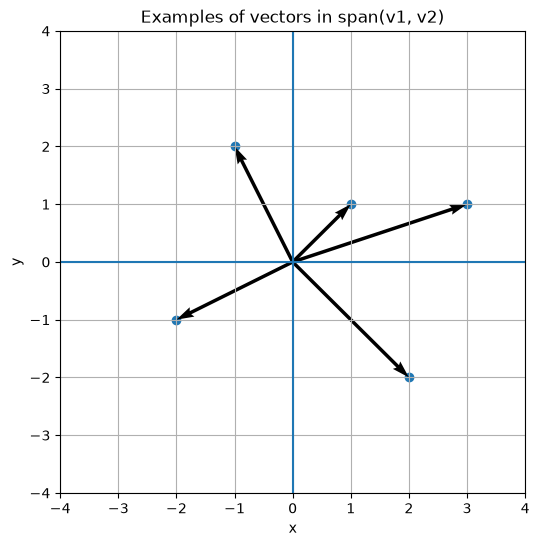

In [4]:
plt.figure(figsize=(6, 6))

plt.scatter(points[:, 0], points[:, 1])

for point in points:
    plt.quiver(
        0, 0,
        point[0], point[1],
        angles="xy",
        scale_units="xy",
        scale=1
    )

plt.axhline(0)
plt.axvline(0)
plt.grid()
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Examples of vectors in span(v1, v2)")
plt.show()

## 3. Linear dependence

A set of vectors is **linearly dependent** if at least one vector can be expressed as a linear combination of the others.

For example:

$$
\mathbf{v}_1 =
\begin{bmatrix}
1 \\
2
\end{bmatrix},
\qquad
\mathbf{v}_2 =
\begin{bmatrix}
2 \\
4
\end{bmatrix}
$$

are linearly dependent because:

$$
\mathbf{v}_2 = 2\mathbf{v}_1
$$

Both vectors point in the same direction, so they do not provide two independent directions.

In [5]:
v1 = np.array([1, 2])
v2 = np.array([2, 4])

print("v1 =", v1)
print("v2 =", v2)
print("2 * v1 =", 2 * v1)

v1 = [1 2]
v2 = [2 4]
2 * v1 = [2 4]


Formally, the vectors are linearly dependent if:

$$
a_1\mathbf{v}_1 + a_2\mathbf{v}_2 + \cdots + a_n\mathbf{v}_n = \mathbf{0}
$$

has a solution where the coefficients are **not all zero**.

## 4. Linear independence

A set of vectors is **linearly independent** if the only solution to:

$$
a_1\mathbf{v}_1 + a_2\mathbf{v}_2 + \cdots + a_n\mathbf{v}_n = \mathbf{0}
$$

is:

$$
a_1=a_2=\cdots=a_n=0
$$

For example:

$$
\mathbf{v}_1 =
\begin{bmatrix}
1 \\
0
\end{bmatrix},
\qquad
\mathbf{v}_2 =
\begin{bmatrix}
0 \\
1
\end{bmatrix}
$$

are linearly independent.

In [6]:
v1 = np.array([1, 0])
v2 = np.array([0, 1])

A = np.column_stack((v1, v2))

print(A)
print("Rank:", np.linalg.matrix_rank(A))

[[1 0]
 [0 1]]
Rank: 2


## 5. Using rank to detect independence

If vectors are stored as columns of a matrix:

$$
A =
\begin{bmatrix}
| & | & & | \\
\mathbf{v}_1 & \mathbf{v}_2 & \cdots & \mathbf{v}_n \\
| & | & & |
\end{bmatrix}
$$

then:

- if $\operatorname{rank}(A)=n$, the vectors are linearly independent
- if $\operatorname{rank}(A)<n$, the vectors are linearly dependent

In [7]:
v1 = np.array([1, 2, 3])
v2 = np.array([2, 4, 6])
v3 = np.array([0, 1, 1])

A = np.column_stack((v1, v2, v3))

print("A =")
print(A)
print("\nRank:", np.linalg.matrix_rank(A))
print("Number of columns:", A.shape[1])

A =
[[1 2 0]
 [2 4 1]
 [3 6 1]]

Rank: 2
Number of columns: 3


## 6. Basis

A **basis** of a vector space is a set of vectors that satisfies two conditions:

1. The vectors are linearly independent.
2. The vectors span the entire vector space.

The standard basis of $\mathbb{R}^2$ is:

$$
\mathbf{e}_1 =
\begin{bmatrix}
1 \\
0
\end{bmatrix},
\qquad
\mathbf{e}_2 =
\begin{bmatrix}
0 \\
1
\end{bmatrix}
$$

Every vector in $\mathbb{R}^2$ can be written as a unique linear combination of these basis vectors.

In [8]:
e1 = np.array([1, 0])
e2 = np.array([0, 1])

x = np.array([4, 3])

reconstructed_x = 4 * e1 + 3 * e2

print("x =", x)
print("Reconstructed x =", reconstructed_x)

x = [4 3]
Reconstructed x = [4 3]


## 7. A non-standard basis

A basis does not have to be the standard basis.

Consider:

$$
\mathbf{v}_1 =
\begin{bmatrix}
1 \\
1
\end{bmatrix},
\qquad
\mathbf{v}_2 =
\begin{bmatrix}
1 \\
-1
\end{bmatrix}
$$

These vectors are linearly independent and span $\mathbb{R}^2$, so they also form a valid basis.

In [9]:
v1 = np.array([1, 1])
v2 = np.array([1, -1])

B = np.column_stack((v1, v2))

print("Basis matrix:")
print(B)
print("Rank:", np.linalg.matrix_rank(B))
print("Determinant:", np.linalg.det(B))

Basis matrix:
[[ 1  1]
 [ 1 -1]]
Rank: 2
Determinant: -2.0


## 8. Coordinates with respect to a basis

Suppose:

$$
B =
\begin{bmatrix}
| & | \\
\mathbf{v}_1 & \mathbf{v}_2 \\
| & |
\end{bmatrix}
$$

and we want to express:

$$
\mathbf{x}
=
c_1\mathbf{v}_1+c_2\mathbf{v}_2
$$

This can be written as:

$$
B\mathbf{c}=\mathbf{x}
$$

where:

$$
\mathbf{c}
=
\begin{bmatrix}
c_1 \\
c_2
\end{bmatrix}
$$

The vector $\mathbf{c}$ contains the coordinates of $\mathbf{x}$ in that basis.

In [10]:
v1 = np.array([1, 1])
v2 = np.array([1, -1])

B = np.column_stack((v1, v2))

x = np.array([4, 2])

coordinates = np.linalg.solve(B, x)

print("x =", x)
print("Coordinates in the new basis:", coordinates)
print("Reconstruction:", B @ coordinates)

x = [4 2]
Coordinates in the new basis: [3. 1.]
Reconstruction: [4. 2.]


## 9. Dimension

The **dimension** of a vector space is the number of vectors in any basis of that space.

Examples:

$$
\dim(\mathbb{R}^2)=2
$$

$$
\dim(\mathbb{R}^3)=3
$$

A two-dimensional plane requires two independent basis vectors, while a three-dimensional space requires three.

For a matrix, the rank tells us the dimension of the space spanned by its columns:

$$
\operatorname{rank}(A)
=
\dim(\operatorname{Col}(A))
$$

This idea becomes especially important when studying dimensionality reduction.

## 10. Redundant features in Data Science

Suppose a dataset contains two features:

- height in meters
- height in centimeters

These contain the same information because:

$$
\text{height}_{cm}
=
100\cdot\text{height}_{m}
$$

One column is a scalar multiple of the other, which introduces linear dependence into the feature matrix.

In [11]:
X = np.array([
    [1.70, 170],
    [1.80, 180],
    [1.65, 165],
    [1.90, 190]
])

print(X)
print("\nRank:", np.linalg.matrix_rank(X))
print("Number of features:", X.shape[1])

[[  1.7  170.  ]
 [  1.8  180.  ]
 [  1.65 165.  ]
 [  1.9  190.  ]]

Rank: 1
Number of features: 2


Even though the dataset has two columns, those columns do not provide two independent directions of information.

This is one reason why linear dependence matters in Data Science.

## 11. Connection with PCA

Principal Component Analysis searches for a new set of directions that describe the data efficiently.

The ideas of:

- basis
- dimension
- independence
- rank

are therefore essential for understanding PCA.

Later, eigenvectors will provide the new directions used by PCA.

# Exercises

The following exercises are intentionally left unsolved.

## Exercise 1 — Linear combination

Given:

$$
\mathbf{v}_1 =
\begin{bmatrix}
1 \\
2
\end{bmatrix}
$$

and:

$$
\mathbf{v}_2 =
\begin{bmatrix}
3 \\
1
\end{bmatrix}
$$

calculate:

$$
2\mathbf{v}_1 - 3\mathbf{v}_2
$$

using NumPy.

In [18]:
v1 = np.array([1, 2])
v2 = np.array([3, 1])

solution = 2 * v1 - 3 * v2
print(solution)

[-7  1]


## Exercise 2 — Linear dependence

Determine whether:

$$
\mathbf{v}_1 =
\begin{bmatrix}
1 \\
3
\end{bmatrix}
$$

and:

$$
\mathbf{v}_2 =
\begin{bmatrix}
2 \\
6
\end{bmatrix}
$$

are linearly independent or dependent.

Explain the reason mathematically and verify it using NumPy.

In [21]:
v1 = np.array([1, 3])
v2 = np.array([2, 6])
A = np.column_stack((v1,v2))

print('No they are not, 2 * v1 = v2')
print(2 * v1 == v2)
print(np.linalg.matrix_rank(A))

No they are not, 2 * v1 = v2
[ True  True]
1


## Exercise 3 — Independence using rank

Given:

$$
\mathbf{v}_1 =
\begin{bmatrix}
1 \\
0 \\
1
\end{bmatrix},
\quad
\mathbf{v}_2 =
\begin{bmatrix}
0 \\
1 \\
1
\end{bmatrix},
\quad
\mathbf{v}_3 =
\begin{bmatrix}
1 \\
1 \\
2
\end{bmatrix}
$$

determine whether the three vectors are linearly independent.

Use the rank of the matrix whose columns are the vectors.

In [23]:
v1 = np.array([1, 0, 1])
v2 = np.array([0, 1, 1])
v3 = np.array([1, 1, 2])

A = np.column_stack((v1,v2,v3))
print(np.linalg.matrix_rank(A))
print(v1 +v2)
print(v3)

2
[1 1 2]
[1 1 2]


## Exercise 4 — Is this a basis?

Consider:

$$
\mathbf{v}_1 =
\begin{bmatrix}
2 \\
1
\end{bmatrix},
\qquad
\mathbf{v}_2 =
\begin{bmatrix}
1 \\
3
\end{bmatrix}
$$

Determine whether $\{\mathbf{v}_1,\mathbf{v}_2\}$ forms a basis of $\mathbb{R}^2$.

You may use:

- determinant
- rank
- linear independence

In [27]:
v1 = np.array([2, 1])
v2 = np.array([1, 3])

A = np.column_stack((v1,v2))

print(np.linalg.det(A))
print(np.linalg.matrix_rank(A))

5.000000000000001
2


## Exercise 5 — Coordinates in a new basis

Let:

$$
\mathbf{v}_1 =
\begin{bmatrix}
1 \\
1
\end{bmatrix},
\qquad
\mathbf{v}_2 =
\begin{bmatrix}
2 \\
-1
\end{bmatrix}
$$

form a basis.

Express:

$$
\mathbf{x} =
\begin{bmatrix}
5 \\
1
\end{bmatrix}
$$

in this basis.

Find $c_1$ and $c_2$ such that:

$$
\mathbf{x}
=
c_1\mathbf{v}_1+c_2\mathbf{v}_2
$$

In [30]:
v1 = np.array([1, 1])
v2 = np.array([2, -1])
x = np.array([5, 1])

A = np.column_stack((v1,v2))
c = np.linalg.solve(A,x)
print(c)
print(A @ c)
print(x)

[2.33333333 1.33333333]
[5. 1.]
[5 1]


## Exercise 6 — Redundant features

Consider the feature matrix:

$$
X =
\begin{bmatrix}
1 & 2 & 3 \\
2 & 4 & 1 \\
3 & 6 & 5 \\
4 & 8 & 2
\end{bmatrix}
$$

1. Determine the rank of $X$.
2. Compare the rank with the number of columns.
3. Determine whether all features are linearly independent.
4. Identify any obvious relationship between columns.

In [ ]:
X = np.array([
    [1, 2, 3],
    [2, 4, 1],
    [3, 6, 5],
    [4, 8, 2]
])

print(np.linalg.matrix_rank(X))
print(X.shape)
print('As the rank is smaller than dimensions, there are features linearly independent')
print('The second column is the doble of the first one')

2
(4, 3)
The second column is the doble of the first one


## Exercise 7 — Data Science interpretation

A dataset contains:

- temperature in Celsius
- temperature in Fahrenheit
- humidity

The conversion is:

$$
F = 1.8C + 32
$$

Think about:

1. Are Celsius and Fahrenheit providing independent information?
2. What issue could this create in a model?
3. Which feature could be removed?
4. How is this related to linear dependence?

Write your explanation in a Markdown cell.

1. No, they provide dependant information.
2. Duplicating use of resources (memory and CPU)
3. One of the temperatures, Fahrenheit for example.
4. THe temperatures are ll

# Conclusions

In this notebook, we studied:

- linear combinations
- span
- linear dependence
- linear independence
- basis
- coordinates in a basis
- dimension
- matrix rank
- redundant features

These concepts explain how data can be represented using independent directions.

The next topic is:

## Eigenvalues and Eigenvectors

Eigenvectors identify special directions that remain aligned after a linear transformation, which is a key idea behind Principal Component Analysis.